In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv('data/dataset.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())
print("\nDescription:\n", df.describe())
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (114000, 21)

Columns: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Data Types:
 Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

First 5 rows:
    Unnamed: 0                track_id                 artists 

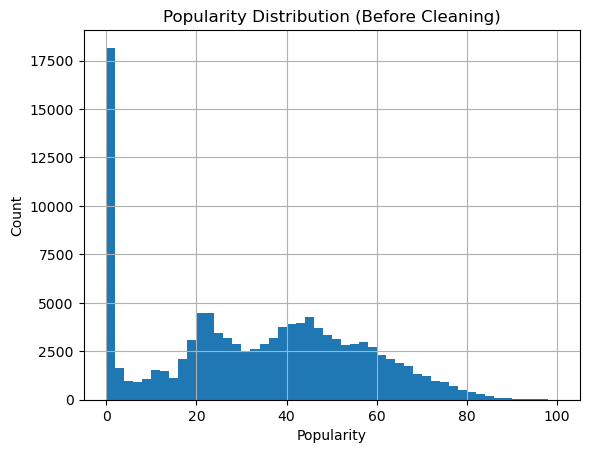

Zero popularity tracks: 16020
Unique genres: 114

Genre distribution:
 track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
anime          1000
black-metal    1000
bluegrass      1000
blues          1000
brazil         1000
Name: count, dtype: int64

Unique artists: 31437

Correlation with popularity:
 popularity          1.000000
loudness            0.050423
explicit            0.044082
danceability        0.035448
Unnamed: 0          0.032142
time_signature      0.031073
tempo               0.013205
energy              0.001056
key                -0.003853
liveness           -0.005387
duration_ms        -0.007101
mode               -0.013931
acousticness       -0.025472
valence            -0.040534
speechiness        -0.044927
instrumentalness   -0.095139
Name: popularity, dtype: float64


In [10]:
# popularity distribution
df['popularity'].hist(bins=50)
plt.title('Popularity Distribution (Before Cleaning)')
plt.xlabel('Popularity')
plt.ylabel('Count')
plt.show()

# zero popularity count
print("Zero popularity tracks:", df[df['popularity'] == 0].shape[0])

# genre count
print("Unique genres:", df['track_genre'].nunique())
print("\nGenre distribution:\n", df['track_genre'].value_counts().head(10))

# artist count
print("\nUnique artists:", df['artists'].nunique())

# correlation with target
print("\nCorrelation with popularity:\n",
      df.corr(numeric_only=True)['popularity'].sort_values(ascending=False))

After dropping zeros: (97980, 21)
After dropping duplicates: (97980, 21)
After dropping useless columns: (97980, 17)


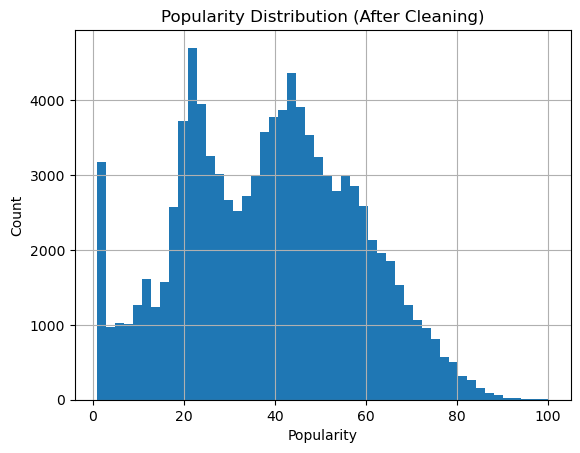

In [11]:
# drop zero popularity rows
df = df[df['popularity'] > 0]
print("After dropping zeros:", df.shape)

# drop duplicate rows
df = df.drop_duplicates()
print("After dropping duplicates:", df.shape)

# drop identity columns
df = df.drop(columns=['track_id', 'track_name', 'album_name', 'artists'])
print("After dropping useless columns:", df.shape)

# check cleaned distribution
df['popularity'].hist(bins=50)
plt.title('Popularity Distribution (After Cleaning)')
plt.xlabel('Popularity')
plt.ylabel('Count')
plt.show()

In [19]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# encode track_genre
le = LabelEncoder()
df['track_genre'] = le.fit_transform(df['track_genre'])

# encode explicit bool → int
df['explicit'] = df['explicit'].astype(int)

print("Final dtypes:\n", df.dtypes)
print("\nFinal shape:", df.shape)

# split features and target
X = df.drop(columns=['popularity'])
y = df['popularity']

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nX_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)

# scale features
scaler      = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Final dtypes:
 Unnamed: 0            int64
popularity            int64
duration_ms           int64
explicit              int64
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre           int64
dtype: object

Final shape: (97980, 17)

X_train shape: (78384, 16)
X_test shape:  (19596, 16)
